# 02 - Feature Engineering and Data Preparation

**Li-ion Battery Degradation Anomaly Detection Using Deep Learning**

---

## Goals
1. Load raw data (same source as `01_EDA.ipynb`)
2. Apply smoothing to handle measurement noise (~25% in Dataset 1)
3. Generate capacity-based derived features (fade_rate, acceleration, rolling statistics)
4. Build a unified long-format DataFrame across all cells
5. Construct sliding-window sequences for Branch B (LSTM-AE, TCN-AE, Transformer-AE)
6. Generate GAF / GADF / MTF images for Branch C (PatchCore, CNN-AE)
7. Save all processed data to Google Drive

## EDA Findings Driving This Notebook
- Dataset 1 has ~25% non-monotonic cycles -> smoothing required
- Only capacity data available -> derive all features from capacity alone
- Anomaly severity varies (38% to 17% fade) -> per-cell normalization
- Sheet 2 contains Diao 2020 baseline detection cycles -> save as ground truth


## 0. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os
import pickle
import warnings
warnings.filterwarnings('ignore')

# Paths
DATASET1_DIR = '/content/drive/MyDrive/Dataset1'
DATASET2_DIR = '/content/drive/MyDrive/Dataset2'
PROJECT_DIR = '/content/drive/MyDrive/battery-anomaly-detection'
PROCESSED_DIR = os.path.join(PROJECT_DIR, 'processed_data')
IMAGE_DIR = os.path.join(PROCESSED_DIR, 'gaf_images')
RESULTS_DIR = os.path.join(PROJECT_DIR, 'results')

for d in [PROCESSED_DIR, IMAGE_DIR, RESULTS_DIR]:
 os.makedirs(d, exist_ok=True)

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print('Setup complete.')

Mounted at /content/drive
Setup complete.


---
## 1. Load Raw Data

In [2]:
# ====== Dataset 1 ======
d1_qual_raw = pd.read_excel(
 os.path.join(DATASET1_DIR, 'Qualified lots.xlsx'),
 sheet_name='Sheet1', header=None)
d1_qual_raw.columns = [f'D1_Qual_{i+1}' for i in range(d1_qual_raw.shape[1])]
d1_qual_raw.index = range(1, len(d1_qual_raw) + 1)
d1_qual_raw.index.name = 'cycle'

d1_subseq_raw = pd.read_excel(
 os.path.join(DATASET1_DIR, 'Subsequent lots for ongoing reliability testing.xlsx'),
 sheet_name='Sheet1', header=None)
d1_subseq_raw.columns = [f'D1_Subseq_{i+1}' for i in range(d1_subseq_raw.shape[1])]
d1_subseq_raw.index = range(1, len(d1_subseq_raw) + 1)
d1_subseq_raw.index.name = 'cycle'

# Sheet2 — Diao 2020 baseline detection cycles
d1_sheet2 = pd.read_excel(
 os.path.join(DATASET1_DIR, 'Subsequent lots for ongoing reliability testing.xlsx'),
 sheet_name='Sheet2', header=None)
d1_sheet2.index = ['Regression', 'OC-SVM', 'LOF', 'Mahalanobis', 'SPRT']
d1_sheet2.columns = [f'D1_Subseq_{i+1}' for i in range(d1_sheet2.shape[1])]

# ====== Dataset 2 ======
mat_data = sio.loadmat(os.path.join(DATASET2_DIR, 'Dataset2.mat'), squeeze_me=True)
lot1 = mat_data['Lot1']

d2_cells = {}
for i in range(23):
 cell_data = lot1[i]
 cell_id = i + 1
 prefix = 'D2_Qual' if cell_id <= 14 else 'D2_Subseq'
 label = f'{prefix}_{cell_id}'
 d2_cells[label] = pd.Series(
 cell_data[:, 1], index=cell_data[:, 0].astype(int), name=label)

print(f'Dataset 1: Qualified {d1_qual_raw.shape}, Subsequent {d1_subseq_raw.shape}')
print(f'Dataset 2: {len(d2_cells)} cells (14 qual + 9 subseq)')
print(f'\nDiao 2020 Baseline Detection Cycles:')
display(d1_sheet2)

Dataset 1: Qualified (496, 6), Subsequent (500, 6)
Dataset 2: 23 cells (14 qual + 9 subseq)

Diao 2020 Baseline Detection Cycles:


,D1_Subseq_1,D1_Subseq_2,D1_Subseq_3,D1_Subseq_4,D1_Subseq_5,D1_Subseq_6
Regression,115,55,139,226,338,277
OC-SVM,110,57,120,153,323,265
LOF,108,56,121,196,322,268
Mahalanobis,109,36,120,212,321,273
SPRT,107,49,119,207,318,269


---
## 2. Smoothing

EDA showed that ~25% of Dataset 1 cycles are non-monotonic due to measurement noise.
Apply a rolling mean for smoothing and choose the window size after comparing candidates.


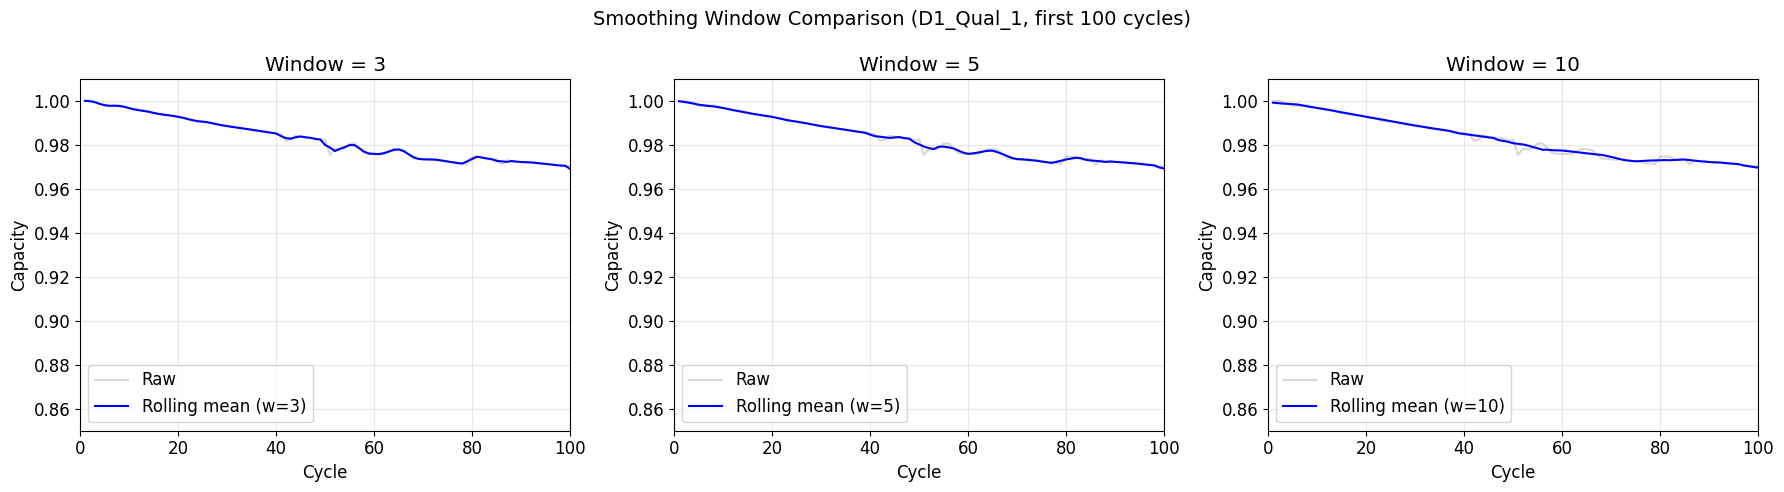

Non-monotonic cycles after smoothing:
  w= 1: 130/495 = 26.3%
  w= 3: 113/495 = 22.8%
  w= 5: 106/495 = 21.4%
  w=10: 61/495 = 12.3%

→ Selected: SMOOTH_WINDOW = 5


In [3]:
# --- Compare smoothing window sizes ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sample = d1_qual_raw['D1_Qual_1']
windows = [3, 5, 10]

for idx, w in enumerate(windows):
 ax = axes[idx]
 ax.plot(sample.index, sample.values, alpha=0.3, color='gray', label='Raw')
 smoothed = sample.rolling(w, center=True, min_periods=1).mean()
 ax.plot(smoothed.index, smoothed.values, color='blue', linewidth=1.5,
 label=f'Rolling mean (w={w})')
 ax.set_title(f'Window = {w}')
 ax.set_xlabel('Cycle')
 ax.set_ylabel('Capacity')
 ax.legend()
 ax.set_ylim(0.85, 1.01)
 ax.set_xlim(0, 100) # zoom in

plt.suptitle('Smoothing Window Comparison (D1_Qual_1, first 100 cycles)', fontsize=14)
plt.tight_layout()
plt.show()

# Check non-monotonic reduction
print('Non-monotonic cycles after smoothing:')
for w in [1, 3, 5, 10]:
 smoothed = sample.rolling(w, center=True, min_periods=1).mean()
 increases = (smoothed.diff() > 0).sum()
 total = len(smoothed) - 1
 print(f' w={w:>2}: {increases}/{total} = {increases/total*100:.1f}%')

SMOOTH_WINDOW = 5
print(f'\n-> Selected: SMOOTH_WINDOW = {SMOOTH_WINDOW}')

In [4]:
# --- Apply smoothing to all cells ---
def smooth_series(series, window=SMOOTH_WINDOW):
 return series.rolling(window, center=True, min_periods=1).mean()

# Dataset 1
d1_qual_smooth = d1_qual_raw.apply(smooth_series)
d1_subseq_smooth = d1_subseq_raw.apply(smooth_series)

# Dataset 2
d2_cells_smooth = {k: smooth_series(v) for k, v in d2_cells.items()}

# Verify smoothing
print('Non-monotonic % AFTER smoothing (w=5):')
for col in d1_qual_smooth.columns:
 inc = (d1_qual_smooth[col].diff() > 0).sum()
 total = len(d1_qual_smooth[col]) - 1
 print(f' {col}: {inc/total*100:.1f}%')

print()
for col in d1_subseq_smooth.columns:
 inc = (d1_subseq_smooth[col].diff() > 0).sum()
 total = len(d1_subseq_smooth[col]) - 1
 print(f' {col}: {inc/total*100:.1f}%')

Non-monotonic % AFTER smoothing (w=5):
  D1_Qual_1: 21.4%
  D1_Qual_2: 18.2%
  D1_Qual_3: 19.2%
  D1_Qual_4: 14.7%
  D1_Qual_5: 15.4%
  D1_Qual_6: 15.8%

  D1_Subseq_1: 12.2%
  D1_Subseq_2: 14.2%
  D1_Subseq_3: 13.8%
  D1_Subseq_4: 14.8%
  D1_Subseq_5: 15.2%
  D1_Subseq_6: 15.0%


---
## 3. Feature Engineering

Derive six features from the single available capacity signal:

| Feature | Description | Formula |
|---|---|---|
| `capacity` | Smoothed normalized capacity | rolling_mean(raw, w=5) |
| `fade_rate` | First derivative (degradation speed) | d_capacity / d_cycle |
| `fade_accel` | Second derivative (degradation acceleration) | d_fade_rate / d_cycle |
| `rolling_std` | Local variability (noise level) | std(capacity, w=10) |
| `relative_cap` | Capacity relative to the cell's initial value | capacity / capacity[0] |
| `cumul_fade` | Cumulative fade from start | 1 - relative_cap |


In [5]:
def extract_features(capacity_series, cell_id, dataset, group):
 """
 Extract features from a single cell's capacity fade curve.

 Args:
 capacity_series: smoothed capacity values (index=cycle)
 cell_id: identifier string
 dataset: 'Dataset1' or 'Dataset2'
 group: 'Qualified' or 'Subsequent'

 Returns:
 DataFrame with cycle-level features
 """
 s = capacity_series.copy()
 cap_initial = s.iloc[0]

 df = pd.DataFrame({
 'cycle': s.index,
 'capacity': s.values,
 'fade_rate': s.diff().values,
 'fade_accel': s.diff().diff().values,
 'rolling_std': s.rolling(10, center=True, min_periods=3).std().values,
 'relative_cap': (s / cap_initial).values,
 'cumul_fade': (1 - s / cap_initial).values,
 })

 df['cell_id'] = cell_id
 df['dataset'] = dataset
 df['group'] = group

 return df

# --- Extract features for ALL cells ---
all_features = []

# Dataset 1 — Qualified
for col in d1_qual_smooth.columns:
 df = extract_features(d1_qual_smooth[col], col, 'Dataset1', 'Qualified')
 all_features.append(df)

# Dataset 1 — Subsequent
for col in d1_subseq_smooth.columns:
 df = extract_features(d1_subseq_smooth[col], col, 'Dataset1', 'Subsequent')
 all_features.append(df)

# Dataset 2 — All cells
for label, series in d2_cells_smooth.items():
 cell_num = int(label.split('_')[-1])
 group = 'Qualified' if cell_num <= 14 else 'Subsequent'
 df = extract_features(series, label, 'Dataset2', group)
 all_features.append(df)

# Combine
features_df = pd.concat(all_features, ignore_index=True)

print(f'Total feature DataFrame: {features_df.shape}')
print(f'\nColumns: {list(features_df.columns)}')
print(f'\nCells per group:')
print(features_df.groupby(['dataset', 'group'])['cell_id'].nunique())
print(f'\nFeature stats (Dataset1 Qualified):')
display(features_df[features_df['group']=='Qualified'].describe().round(6))

Total feature DataFrame: (11726, 10)

Columns: ['cycle', 'capacity', 'fade_rate', 'fade_accel', 'rolling_std', 'relative_cap', 'cumul_fade', 'cell_id', 'dataset', 'group']

Cells per group:
dataset   group     
Dataset1  Qualified      6
          Subsequent     6
Dataset2  Qualified     14
          Subsequent     9
Name: cell_id, dtype: int64

Feature stats (Dataset1 Qualified):


,cycle,capacity,fade_rate,fade_accel,rolling_std,relative_cap,cumul_fade
count,6476.000000,6476.000000,6456.000000,6436.000000,6476.000000,6476.000000,6476.000000
mean,182.023780,0.949041,-0.000253,0.000003,0.000844,0.947899,0.052101
std,126.475283,0.027282,0.000398,0.000396,0.000750,0.026338,0.026338
min,1.000000,0.856626,-0.005836,-0.005916,0.000101,0.856538,-0.002757
25%,81.000000,0.934949,-0.000325,-0.000026,0.000382,0.935698,0.035136
50%,162.000000,0.950301,-0.000168,0.000000,0.000573,0.949018,0.050982
75%,243.000000,0.967241,-0.000116,0.000039,0.001030,0.964864,0.064302
max,496.000000,1.017655,0.005212,0.005986,0.005445,1.002757,0.143462


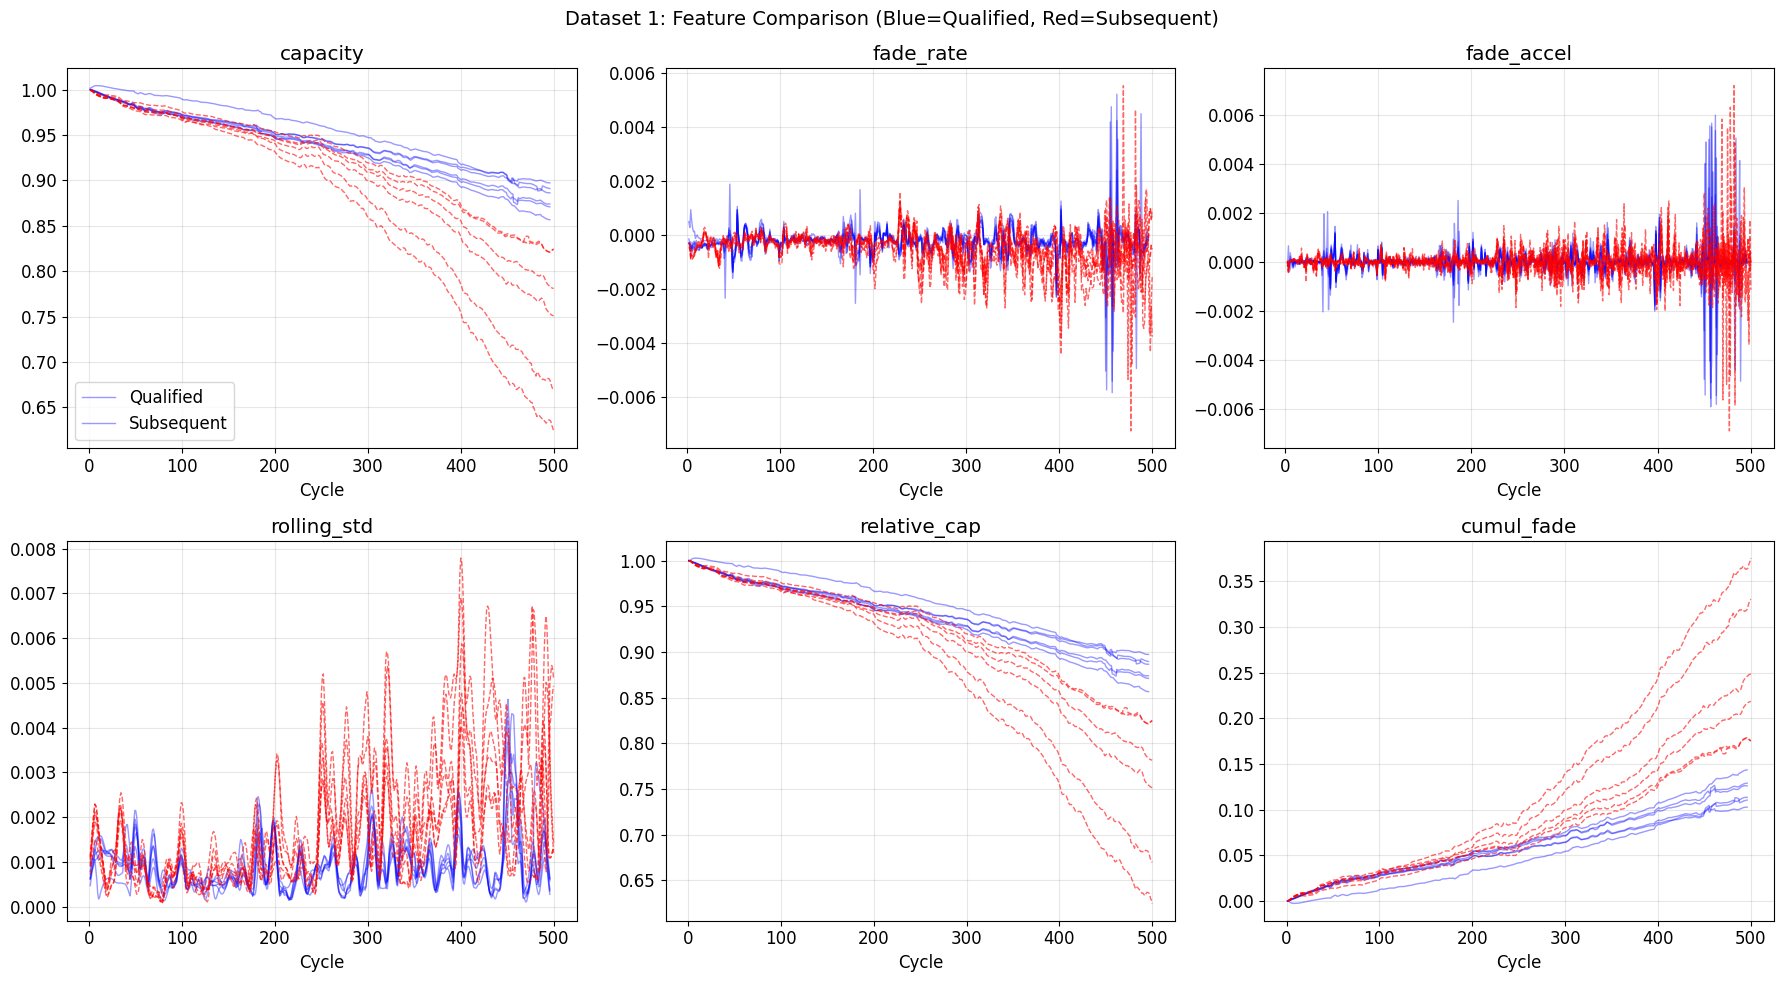

✓ Saved: fig09_feature_comparison_d1.png


In [6]:
# --- Visualize features: Qualified vs Subsequent ---
feature_cols = ['capacity', 'fade_rate', 'fade_accel', 'rolling_std', 'relative_cap', 'cumul_fade']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, feat in enumerate(feature_cols):
 ax = axes[idx // 3, idx % 3]

 # Dataset 1 only for clarity
 d1_feat = features_df[features_df['dataset'] == 'Dataset1']

 for cell_id in d1_feat[d1_feat['group']=='Qualified']['cell_id'].unique():
 cell_data = d1_feat[d1_feat['cell_id']==cell_id]
 ax.plot(cell_data['cycle'], cell_data[feat], color='blue', alpha=0.4, linewidth=1)

 for cell_id in d1_feat[d1_feat['group']=='Subsequent']['cell_id'].unique():
 cell_data = d1_feat[d1_feat['cell_id']==cell_id]
 ax.plot(cell_data['cycle'], cell_data[feat], color='red', alpha=0.6,
 linewidth=1, linestyle='--')

 ax.set_title(feat)
 ax.set_xlabel('Cycle')

axes[0, 0].legend(['Qualified', 'Subsequent'], loc='lower left')
plt.suptitle('Dataset 1: Feature Comparison (Blue=Qualified, Red=Subsequent)', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig09_feature_comparison_d1.png'),
 dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: fig09_feature_comparison_d1.png')

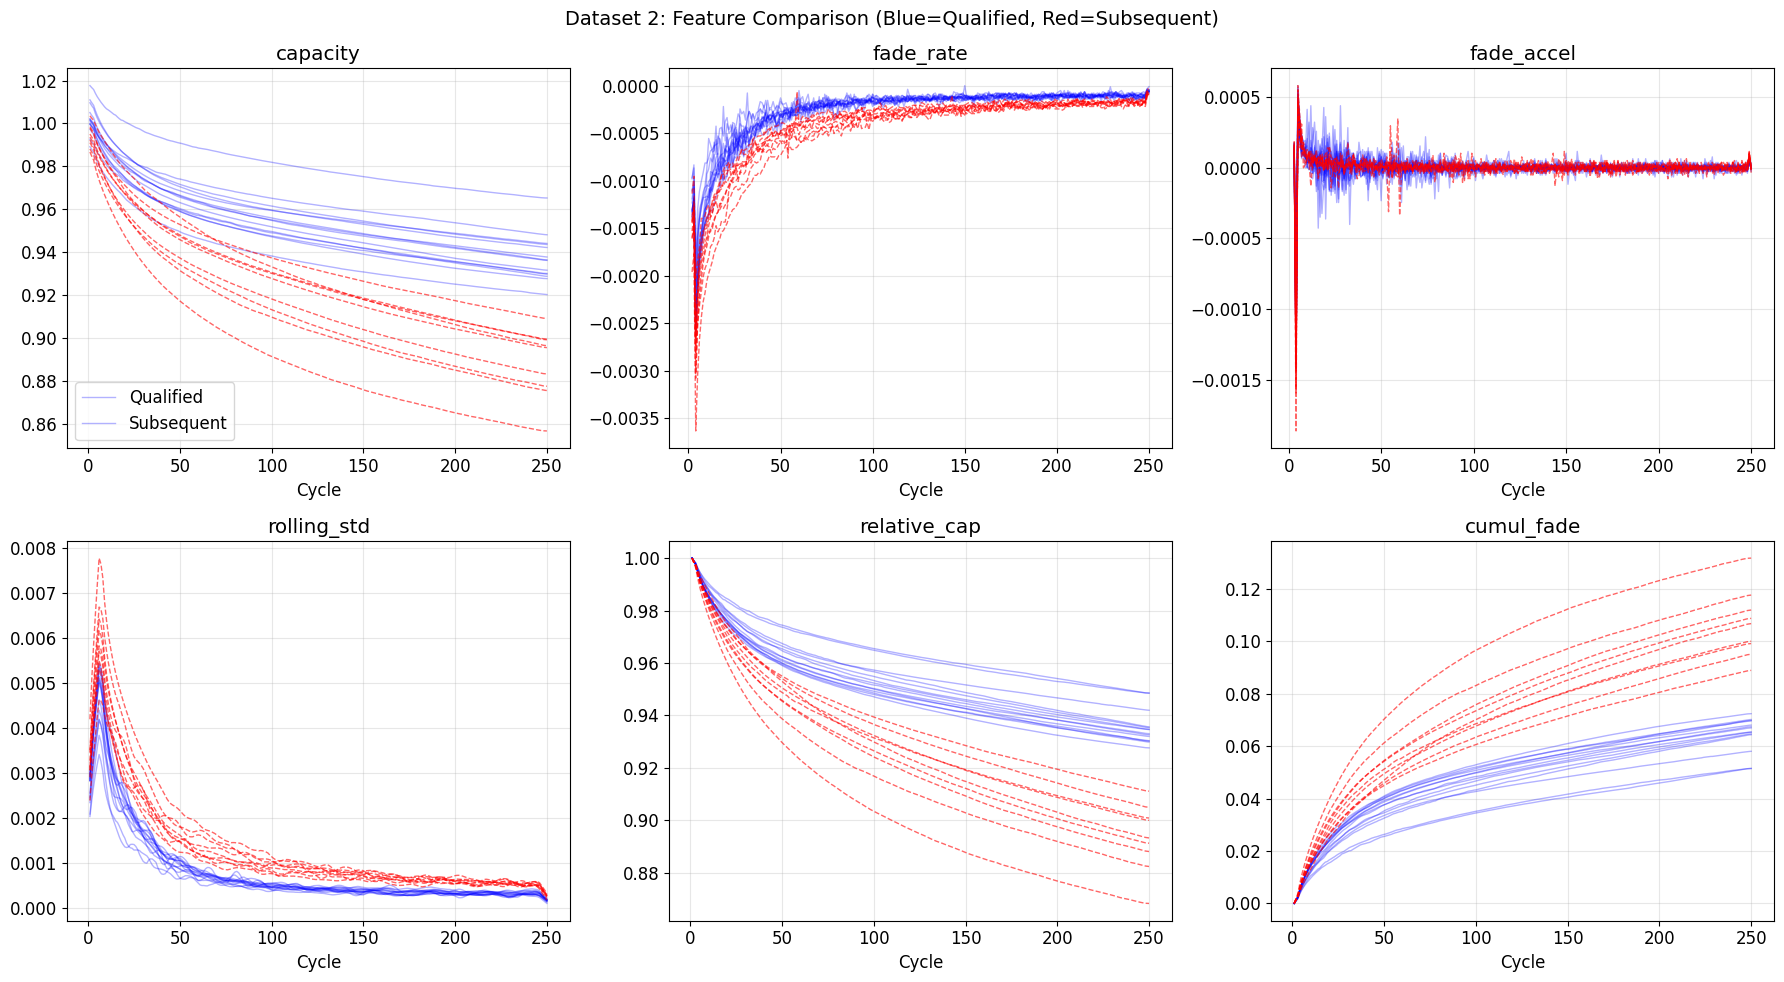

✓ Saved: fig10_feature_comparison_d2.png


In [7]:
# --- Same for Dataset 2 ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, feat in enumerate(feature_cols):
 ax = axes[idx // 3, idx % 3]

 d2_feat = features_df[features_df['dataset'] == 'Dataset2']

 for cell_id in d2_feat[d2_feat['group']=='Qualified']['cell_id'].unique():
 cell_data = d2_feat[d2_feat['cell_id']==cell_id]
 ax.plot(cell_data['cycle'], cell_data[feat], color='blue', alpha=0.3, linewidth=1)

 for cell_id in d2_feat[d2_feat['group']=='Subsequent']['cell_id'].unique():
 cell_data = d2_feat[d2_feat['cell_id']==cell_id]
 ax.plot(cell_data['cycle'], cell_data[feat], color='red', alpha=0.6,
 linewidth=1, linestyle='--')

 ax.set_title(feat)
 ax.set_xlabel('Cycle')

axes[0, 0].legend(['Qualified', 'Subsequent'], loc='lower left')
plt.suptitle('Dataset 2: Feature Comparison (Blue=Qualified, Red=Subsequent)', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig10_feature_comparison_d2.png'),
 dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: fig10_feature_comparison_d2.png')

---
## 4. Sliding Window Sequences (Branch B Input)

Input format for LSTM-AE, TCN-AE, and Transformer-AE:
- Window size: 20 cycles
- Stride: 1 cycle
- Features: the six features derived above
- Normalization: per-dataset, fit on qualified cells only, then transform all cells


In [8]:
WINDOW_SIZE = 5
STRIDE = 1
FEATURE_COLS = ['capacity', 'fade_rate', 'fade_accel', 'rolling_std', 'relative_cap', 'cumul_fade']

def create_sliding_windows(cell_df, window_size=WINDOW_SIZE, stride=STRIDE):
 """
 Create sliding window sequences from a single cell's features.

 Returns:
 windows: array of shape (n_windows, window_size, n_features)
 metadata: list of dicts with cell_id, start_cycle, end_cycle
 """
 # Drop NaN rows (from diff/rolling)
 valid = cell_df[FEATURE_COLS].dropna()
 values = valid.values
 cycles = cell_df.loc[valid.index, 'cycle'].values

 windows = []
 metadata = []

 for start in range(0, len(values) - window_size + 1, stride):
 end = start + window_size
 windows.append(values[start:end])
 metadata.append({
 'cell_id': cell_df['cell_id'].iloc[0],
 'dataset': cell_df['dataset'].iloc[0],
 'group': cell_df['group'].iloc[0],
 'start_cycle': int(cycles[start]),
 'end_cycle': int(cycles[end - 1]),
 })

 return np.array(windows), metadata

# --- Create windows for all cells ---
all_windows = {'Dataset1': {'Qualified': [], 'Subsequent': []},
 'Dataset2': {'Qualified': [], 'Subsequent': []}}
all_metadata = {'Dataset1': {'Qualified': [], 'Subsequent': []},
 'Dataset2': {'Qualified': [], 'Subsequent': []}}

for cell_id in features_df['cell_id'].unique():
 cell_df = features_df[features_df['cell_id'] == cell_id].copy()
 ds = cell_df['dataset'].iloc[0]
 grp = cell_df['group'].iloc[0]

 windows, meta = create_sliding_windows(cell_df)
 if len(windows) > 0:
 all_windows[ds][grp].append(windows)
 all_metadata[ds][grp].extend(meta)

# Stack
for ds in ['Dataset1', 'Dataset2']:
 for grp in ['Qualified', 'Subsequent']:
 if all_windows[ds][grp]:
 all_windows[ds][grp] = np.concatenate(all_windows[ds][grp], axis=0)
 else:
 all_windows[ds][grp] = np.array([])

print('=== Sliding Windows Created ===')
for ds in ['Dataset1', 'Dataset2']:
 for grp in ['Qualified', 'Subsequent']:
 shape = all_windows[ds][grp].shape if len(all_windows[ds][grp]) > 0 else 'empty'
 n_cells = len(set(m['cell_id'] for m in all_metadata[ds][grp])) if all_metadata[ds][grp] else 0
 print(f' {ds} {grp}: {shape} ({n_cells} cells)')

=== Sliding Windows Created ===
  Dataset1 Qualified: (2940, 5, 6) (6 cells)
  Dataset1 Subsequent: (2964, 5, 6) (6 cells)
  Dataset2 Qualified: (3416, 5, 6) (14 cells)
  Dataset2 Subsequent: (2196, 5, 6) (9 cells)


In [9]:
# --- Normalize: fit on Qualified, transform all ---
from sklearn.preprocessing import StandardScaler

scalers = {}
windows_normalized = {}

for ds in ['Dataset1', 'Dataset2']:
 qual_data = all_windows[ds]['Qualified']
 if len(qual_data) == 0:
 continue

 # Reshape to 2D for fitting: (n_windows * window_size, n_features)
 n_w, w_size, n_f = qual_data.shape
 qual_flat = qual_data.reshape(-1, n_f)

 scaler = StandardScaler()
 scaler.fit(qual_flat)
 scalers[ds] = scaler

 windows_normalized[ds] = {}
 for grp in ['Qualified', 'Subsequent']:
 data = all_windows[ds][grp]
 if len(data) == 0:
 windows_normalized[ds][grp] = np.array([])
 continue
 n_w2, w_size2, n_f2 = data.shape
 flat = data.reshape(-1, n_f2)
 norm_flat = scaler.transform(flat)
 windows_normalized[ds][grp] = norm_flat.reshape(n_w2, w_size2, n_f2)

print('=== Normalized Windows ===')
for ds in windows_normalized:
 for grp in windows_normalized[ds]:
 d = windows_normalized[ds][grp]
 if len(d) > 0:
 print(f' {ds} {grp}: shape={d.shape}, mean={d.mean():.4f}, std={d.std():.4f}')

print(f'\nScaler means (Dataset1): {scalers["Dataset1"].mean_.round(6)}')
print(f'Scaler stds (Dataset1): {scalers["Dataset1"].scale_.round(6)}')
print(f'Feature order: {FEATURE_COLS}')

=== Normalized Windows ===
  Dataset1 Qualified: shape=(2940, 5, 6), mean=-0.0000, std=1.0000
  Dataset1 Subsequent: shape=(2964, 5, 6), mean=-0.0550, std=2.2494
  Dataset2 Qualified: shape=(3416, 5, 6), mean=-0.0000, std=1.0000
  Dataset2 Subsequent: shape=(2196, 5, 6), mean=-0.3483, std=2.0815

Scaler means (Dataset1): [ 9.41587e-01 -2.45000e-04  0.00000e+00  9.19000e-04  9.41429e-01
  5.85710e-02]
Scaler stds  (Dataset1): [0.033661 0.000479 0.000576 0.00057  0.033564 0.033564]
Feature order: ['capacity', 'fade_rate', 'fade_accel', 'rolling_std', 'relative_cap', 'cumul_fade']


---
## 5. GAF / GADF / MTF Image Generation (Branch C Input)

Convert each cell's full capacity curve to a 3-channel image (GASF | GADF | MTF).
- PAA downsampling to 64x64
- For PatchCore, the 64x64 images are resized to 224x224 at training time


In [10]:
GAF_IMAGE_SIZE = 64

def paa_reduce(x, target_size):
 """Piecewise Aggregate Approximation."""
 if len(x) <= target_size:
 return x
 indices = np.array_split(np.arange(len(x)), target_size)
 return np.array([x[idx].mean() for idx in indices])

def compute_gasf(x):
 x_min, x_max = x.min(), x.max()
 if x_max - x_min < 1e-10:
 return np.zeros((len(x), len(x)))
 x_norm = 2 * (x - x_min) / (x_max - x_min) - 1
 x_norm = np.clip(x_norm, -1, 1)
 phi = np.arccos(x_norm)
 return np.cos(phi[:, None] + phi[None,:])

def compute_gadf(x):
 x_min, x_max = x.min(), x.max()
 if x_max - x_min < 1e-10:
 return np.zeros((len(x), len(x)))
 x_norm = 2 * (x - x_min) / (x_max - x_min) - 1
 x_norm = np.clip(x_norm, -1, 1)
 phi = np.arccos(x_norm)
 return np.sin(phi[:, None] - phi[None,:])

def compute_mtf(x, n_bins=8):
 bins = np.percentile(x, np.linspace(0, 100, n_bins + 1))
 bins[0] -= 1e-10
 bins[-1] += 1e-10
 digitized = np.clip(np.digitize(x, bins) - 1, 0, n_bins - 1)

 W = np.zeros((n_bins, n_bins))
 for i in range(len(digitized) - 1):
 W[digitized[i], digitized[i+1]] += 1
 row_sums = W.sum(axis=1, keepdims=True)
 row_sums[row_sums == 0] = 1
 W = W / row_sums

 N = len(x)
 mtf = np.zeros((N, N))
 for i in range(N):
 for j in range(N):
 mtf[i, j] = W[digitized[i], digitized[j]]
 return mtf

def generate_3ch_image(capacity_values, image_size=GAF_IMAGE_SIZE):
 """Generate 3-channel [GASF, GADF, MTF] image from capacity sequence."""
 x = paa_reduce(capacity_values, image_size)
 gasf = compute_gasf(x)
 gadf = compute_gadf(x)
 mtf = compute_mtf(x)
 return np.stack([gasf, gadf, mtf], axis=0) # (3, H, W)

print(f'GAF functions defined (normalization fixed). Image size: {GAF_IMAGE_SIZE}×{GAF_IMAGE_SIZE}')

GAF functions defined (normalization fixed). Image size: 64×64


In [11]:
# --- Generate full-curve GAF images for all cells ---
gaf_images = {} # {cell_id: (3, 64, 64) array}
gaf_labels = {} # {cell_id: {'dataset':..., 'group':...}}

# Dataset 1
for col in d1_qual_smooth.columns:
 img = generate_3ch_image(d1_qual_smooth[col].values)
 gaf_images[col] = img
 gaf_labels[col] = {'dataset': 'Dataset1', 'group': 'Qualified'}

for col in d1_subseq_smooth.columns:
 img = generate_3ch_image(d1_subseq_smooth[col].values)
 gaf_images[col] = img
 gaf_labels[col] = {'dataset': 'Dataset1', 'group': 'Subsequent'}

# Dataset 2
for label, series in d2_cells_smooth.items():
 cell_num = int(label.split('_')[-1])
 group = 'Qualified' if cell_num <= 14 else 'Subsequent'
 img = generate_3ch_image(series.dropna().values)
 gaf_images[label] = img
 gaf_labels[label] = {'dataset': 'Dataset2', 'group': group}

print(f'Generated {len(gaf_images)} GAF images')
print(f'Image shape: {list(gaf_images.values())[0].shape}')

# Count per group
for ds in ['Dataset1', 'Dataset2']:
 for grp in ['Qualified', 'Subsequent']:
 n = sum(1 for v in gaf_labels.values() if v['dataset']==ds and v['group']==grp)
 print(f' {ds} {grp}: {n} images')

Generated 35 GAF images
Image shape: (3, 64, 64)
  Dataset1 Qualified: 6 images
  Dataset1 Subsequent: 6 images
  Dataset2 Qualified: 14 images
  Dataset2 Subsequent: 9 images


In [12]:
# --- Progressive GAF: sliding window images for early detection ---
# Generate GAF images at different cycle cutoffs for early detection evaluation

PROGRESSIVE_CYCLES = [20, 30, 40, 50, 60, 75, 100, 125, 150, 175, 200]
progressive_gaf = {} # {cell_id: {n_cycles: (3, 64, 64)}}

def get_cell_capacity(cell_id):
 """Helper to get smoothed capacity for a cell."""
 if cell_id in d1_qual_smooth.columns:
 return d1_qual_smooth[cell_id].values
 elif cell_id in d1_subseq_smooth.columns:
 return d1_subseq_smooth[cell_id].values
 elif cell_id in d2_cells_smooth:
 return d2_cells_smooth[cell_id].values
 return None

for cell_id in list(d1_qual_smooth.columns) + list(d1_subseq_smooth.columns) + list(d2_cells_smooth.keys()):
 cap = get_cell_capacity(cell_id)
 if cap is None:
 continue
 progressive_gaf[cell_id] = {}
 for n_cyc in PROGRESSIVE_CYCLES:
 if len(cap) >= n_cyc:
 img = generate_3ch_image(cap[:n_cyc])
 progressive_gaf[cell_id][n_cyc] = img

print(f'Progressive GAF: {len(progressive_gaf)} cells × {len(PROGRESSIVE_CYCLES)} cutoffs')
print(f'Cutoffs: {PROGRESSIVE_CYCLES}')
print(f'Example ({list(progressive_gaf.keys())[0]}): {sorted(list(progressive_gaf.values())[0].keys())} cycles')

Progressive GAF: 35 cells × 11 cutoffs
Cutoffs: [20, 30, 40, 50, 60, 75, 100, 125, 150, 175, 200]
Example (D1_Qual_1): [20, 30, 40, 50, 60, 75, 100, 125, 150, 175, 200] cycles


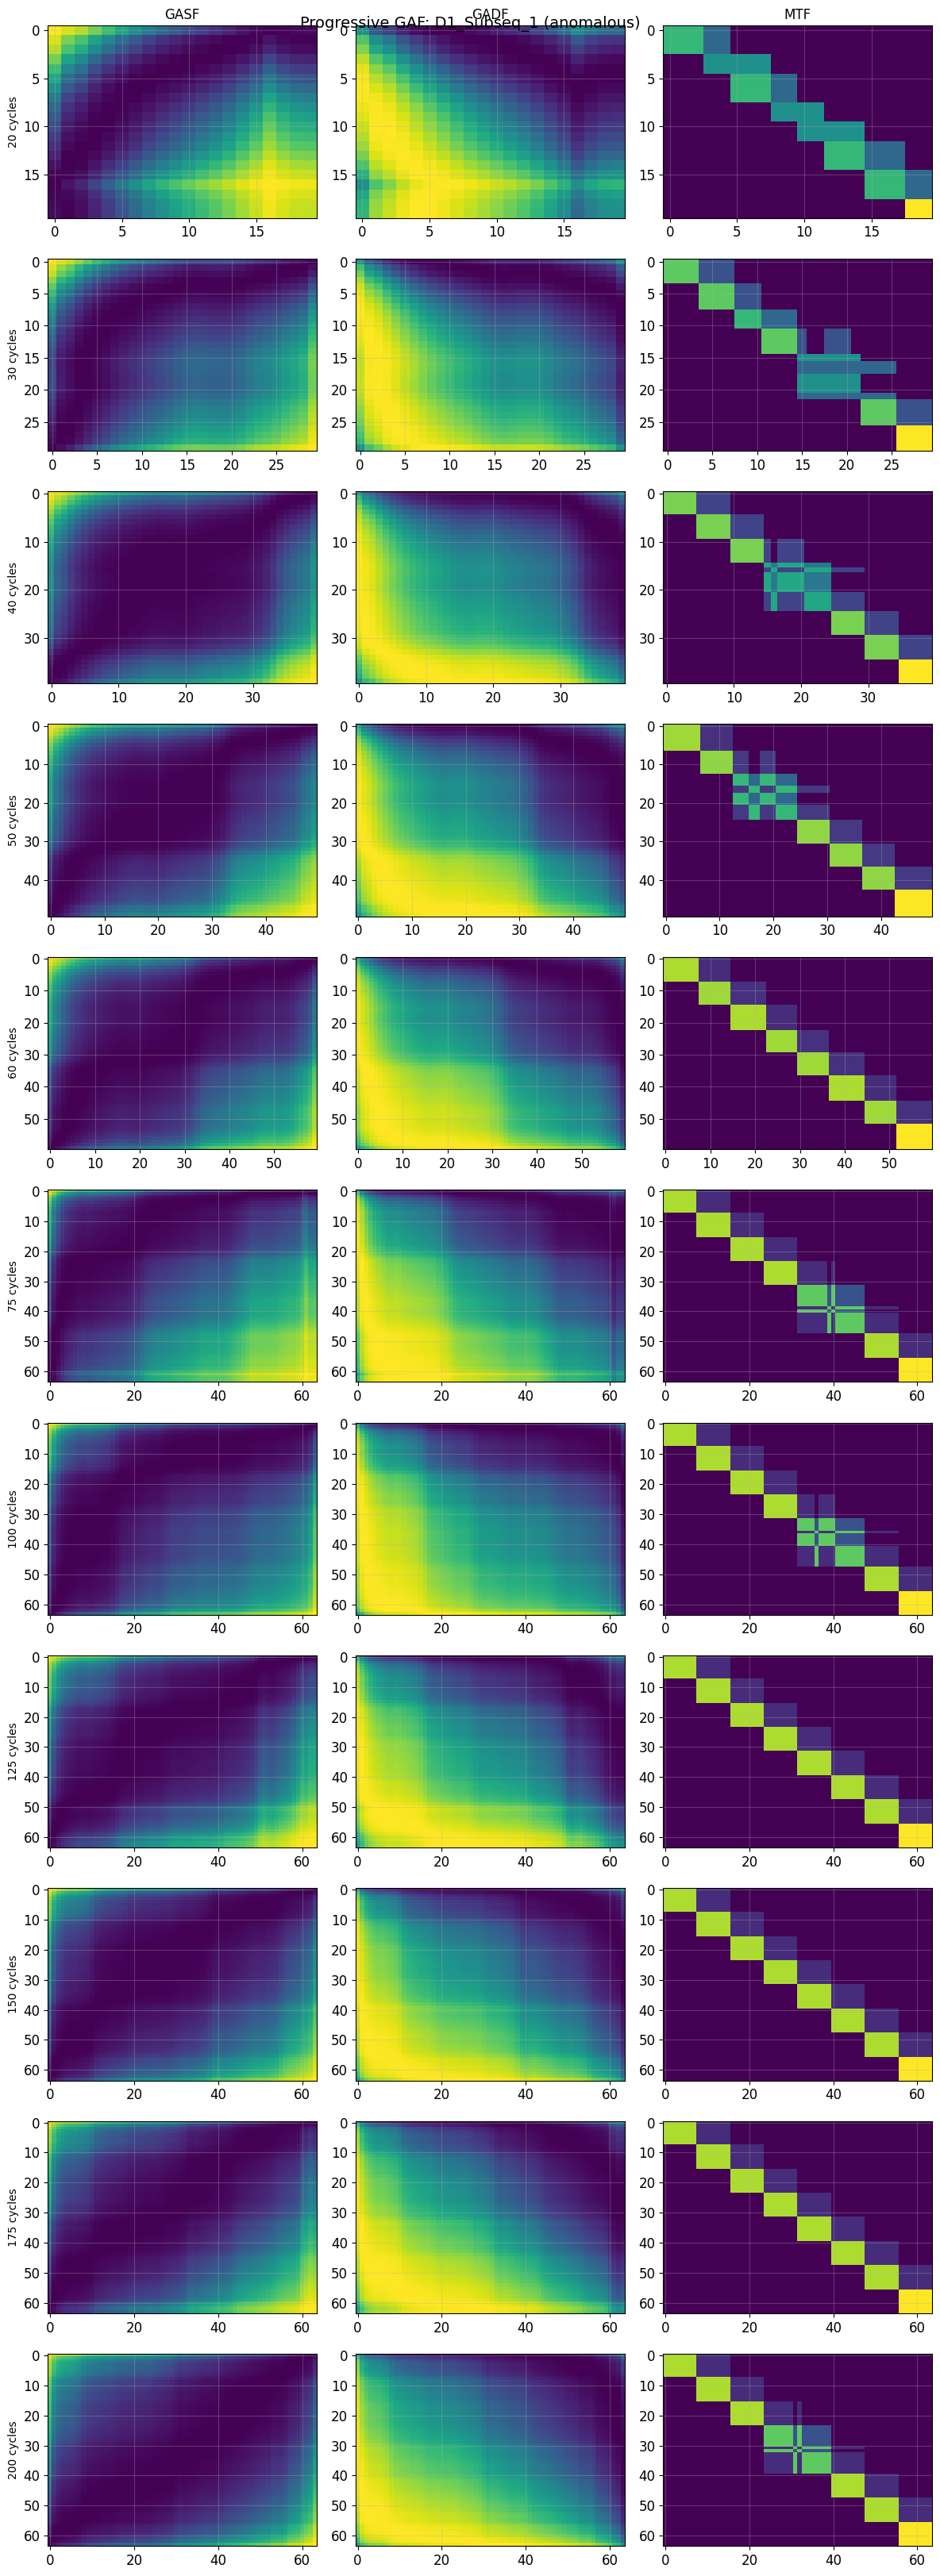

✓ Saved: fig11_progressive_gaf.png


In [13]:
# --- Visualize progressive GAF for one anomalous cell ---
cell_show = 'D1_Subseq_1'
fig, axes = plt.subplots(len(PROGRESSIVE_CYCLES), 3,
 figsize=(12, 3 * len(PROGRESSIVE_CYCLES)))

for row, n_cyc in enumerate(PROGRESSIVE_CYCLES):
 if n_cyc not in progressive_gaf.get(cell_show, {}):
 continue
 img = progressive_gaf[cell_show][n_cyc]
 titles = ['GASF', 'GADF', 'MTF']
 for ch in range(3):
 axes[row, ch].imshow(img[ch], cmap='viridis', aspect='auto')
 if row == 0:
 axes[row, ch].set_title(titles[ch], fontsize=12)
 axes[row, 0].set_ylabel(f'{n_cyc} cycles', fontsize=10)

plt.suptitle(f'Progressive GAF: {cell_show} (anomalous)', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig11_progressive_gaf.png'),
 dpi=100, bbox_inches='tight')
plt.show()
print(' Saved: fig11_progressive_gaf.png')

---
## 6. Ground Truth Labels

Consolidate Sheet 2 (Diao 2020 detection cycles) with z-score based onset
into a unified ground-truth table.


In [14]:
# --- Ground truth for Dataset 1 ---
# Diao 2020 baseline detection cycles (Sheet2)
diao_results = d1_sheet2.copy()
print('=== Diao 2020 Baseline Detection Cycles ===')
display(diao_results)

# Z-score onset (from EDA)
d1_q_mean = d1_qual_smooth.mean(axis=1)
d1_q_std = d1_qual_smooth.std(axis=1)

ground_truth_d1 = []
for col in d1_subseq_smooth.columns:
 s = d1_subseq_smooth[col]
 common_idx = s.index.intersection(d1_q_mean.index)
 z = (s.loc[common_idx] - d1_q_mean.loc[common_idx]) / d1_q_std.loc[common_idx].replace(0, 1e-10)

 below_2 = z[z < -2]
 below_3 = z[z < -3]

 gt = {
 'cell_id': col,
 'is_anomalous': True,
 'z_onset_2sigma': int(below_2.index[0]) if len(below_2) > 0 else None,
 'z_onset_3sigma': int(below_3.index[0]) if len(below_3) > 0 else None,
 'final_z': float(z.iloc[-1]),
 'diao_earliest': int(diao_results[col].min()),
 'diao_latest': int(diao_results[col].max()),
 }
 ground_truth_d1.append(gt)

# Qualified cells are NOT anomalous
for col in d1_qual_smooth.columns:
 ground_truth_d1.append({
 'cell_id': col,
 'is_anomalous': False,
 'z_onset_2sigma': None,
 'z_onset_3sigma': None,
 'final_z': 0.0,
 'diao_earliest': None,
 'diao_latest': None,
 })

gt_d1_df = pd.DataFrame(ground_truth_d1)
print('\n=== Dataset 1 Ground Truth ===')
display(gt_d1_df)

# --- Ground truth for Dataset 2 ---
d2_qual_df = pd.DataFrame({k: v for k, v in d2_cells_smooth.items() if 'Qual' in k})
d2_q_mean = d2_qual_df.mean(axis=1)
d2_q_std = d2_qual_df.std(axis=1)

ground_truth_d2 = []
for label, series in d2_cells_smooth.items():
 cell_num = int(label.split('_')[-1])
 is_anom = cell_num > 14

 s = series.dropna()
 common_idx = s.index.intersection(d2_q_mean.index)
 z = (s.loc[common_idx] - d2_q_mean.loc[common_idx]) / d2_q_std.loc[common_idx].replace(0, 1e-10)

 below_2 = z[z < -2]
 below_3 = z[z < -3]

 ground_truth_d2.append({
 'cell_id': label,
 'is_anomalous': is_anom,
 'z_onset_2sigma': int(below_2.index[0]) if len(below_2) > 0 else None,
 'z_onset_3sigma': int(below_3.index[0]) if len(below_3) > 0 else None,
 'final_z': float(z.iloc[-1]),
 })

gt_d2_df = pd.DataFrame(ground_truth_d2)
print('\n=== Dataset 2 Ground Truth ===')
display(gt_d2_df)

=== Diao 2020 Baseline Detection Cycles ===


,D1_Subseq_1,D1_Subseq_2,D1_Subseq_3,D1_Subseq_4,D1_Subseq_5,D1_Subseq_6
Regression,115,55,139,226,338,277
OC-SVM,110,57,120,153,323,265
LOF,108,56,121,196,322,268
Mahalanobis,109,36,120,212,321,273
SPRT,107,49,119,207,318,269



=== Dataset 1 Ground Truth ===


,cell_id,is_anomalous,z_onset_2sigma,z_onset_3sigma,final_z,diao_earliest,diao_latest
0,D1_Subseq_1,True,168.0,205.0,-16.277229,107.0,115.0
1,D1_Subseq_2,True,205.0,223.0,-13.307966,36.0,57.0
2,D1_Subseq_3,True,225.0,278.0,-8.410386,119.0,139.0
3,D1_Subseq_4,True,277.0,299.0,-6.426543,153.0,226.0
4,D1_Subseq_5,True,318.0,385.0,-3.872903,318.0,338.0
5,D1_Subseq_6,True,294.0,321.0,-3.905861,265.0,277.0
6,D1_Qual_1,False,NaN,NaN,0.000000,NaN,NaN
7,D1_Qual_2,False,NaN,NaN,0.000000,NaN,NaN
8,D1_Qual_3,False,NaN,NaN,0.000000,NaN,NaN
9,D1_Qual_4,False,NaN,NaN,0.000000,NaN,NaN



=== Dataset 2 Ground Truth ===


,cell_id,is_anomalous,z_onset_2sigma,z_onset_3sigma,final_z
0,D2_Qual_1,False,NaN,NaN,0.976336
1,D2_Qual_2,False,NaN,NaN,-0.764730
2,D2_Qual_3,False,NaN,NaN,2.517698
3,D2_Qual_4,False,NaN,NaN,-1.530567
4,D2_Qual_5,False,NaN,NaN,0.567239
5,D2_Qual_6,False,NaN,NaN,0.443161
6,D2_Qual_7,False,NaN,NaN,-0.671658
7,D2_Qual_8,False,NaN,NaN,-0.861663
8,D2_Qual_9,False,NaN,NaN,-0.078386
9,D2_Qual_10,False,NaN,NaN,-0.646464


---
## 7. Save All Processed Data

In [15]:
# === Save everything ===

# 1. Feature DataFrame (long format)
features_df.to_csv(os.path.join(PROCESSED_DIR, 'features_all.csv'), index=False)
print(f' features_all.csv: {features_df.shape}')

# 2. Sliding windows + metadata (pickle for numpy arrays)
window_data = {
 'windows_raw': all_windows,
 'windows_normalized': windows_normalized,
 'metadata': all_metadata,
 'scalers': scalers,
 'feature_cols': FEATURE_COLS,
 'window_size': WINDOW_SIZE,
 'stride': STRIDE,
}
with open(os.path.join(PROCESSED_DIR, 'sliding_windows.pkl'), 'wb') as f:
 pickle.dump(window_data, f)
print(f' sliding_windows.pkl')

# 3. GAF images (full curve)
gaf_data = {
 'images': gaf_images,
 'labels': gaf_labels,
 'image_size': GAF_IMAGE_SIZE,
}
with open(os.path.join(PROCESSED_DIR, 'gaf_images_full.pkl'), 'wb') as f:
 pickle.dump(gaf_data, f)
print(f' gaf_images_full.pkl: {len(gaf_images)} images')

# 4. Progressive GAF images
with open(os.path.join(PROCESSED_DIR, 'gaf_images_progressive.pkl'), 'wb') as f:
 pickle.dump(progressive_gaf, f)
print(f' gaf_images_progressive.pkl: {len(progressive_gaf)} cells × {len(PROGRESSIVE_CYCLES)} cutoffs')

# 5. Ground truth
gt_d1_df.to_csv(os.path.join(PROCESSED_DIR, 'ground_truth_d1.csv'), index=False)
gt_d2_df.to_csv(os.path.join(PROCESSED_DIR, 'ground_truth_d2.csv'), index=False)
print(f' ground_truth_d1.csv, ground_truth_d2.csv')

# 6. Diao 2020 baseline results
diao_results.to_csv(os.path.join(PROCESSED_DIR, 'diao2020_baselines.csv'))
print(f' diao2020_baselines.csv')

# 7. Smoothed capacity data (for quick reload)
smooth_data = {
 'd1_qual': d1_qual_smooth,
 'd1_subseq': d1_subseq_smooth,
 'd2_cells': d2_cells_smooth,
 'smooth_window': SMOOTH_WINDOW,
}
with open(os.path.join(PROCESSED_DIR, 'smoothed_capacity.pkl'), 'wb') as f:
 pickle.dump(smooth_data, f)
print(f' smoothed_capacity.pkl')

print(f'\n=== All data saved to {PROCESSED_DIR} ===')
for f in sorted(os.listdir(PROCESSED_DIR)):
 if os.path.isfile(os.path.join(PROCESSED_DIR, f)):
 size = os.path.getsize(os.path.join(PROCESSED_DIR, f)) / 1024
 print(f' {f} ({size:.1f} KB)')

✓ features_all.csv: (11726, 10)
✓ sliding_windows.pkl
✓ gaf_images_full.pkl: 35 images
✓ gaf_images_progressive.pkl: 35 cells × 11 cutoffs
✓ ground_truth_d1.csv, ground_truth_d2.csv
✓ diao2020_baselines.csv
✓ smoothed_capacity.pkl

=== All data saved to /content/drive/MyDrive/battery-anomaly-detection/processed_data ===
  diao2020_baselines.csv (0.2 KB)
  features_all.csv (1831.6 KB)
  gaf_images_full.pkl (3363.1 KB)
  gaf_images_progressive.pkl (27560.6 KB)
  ground_truth_d1.csv (0.6 KB)
  ground_truth_d2.csv (1.0 KB)
  sliding_windows.pkl (5707.9 KB)
  smoothed_capacity.pkl (188.2 KB)


---
## 8. Verification & Summary

In [16]:
# --- Quick verification: reload and check ---
print('=== Verification ===')

# Reload features
feat_check = pd.read_csv(os.path.join(PROCESSED_DIR, 'features_all.csv'))
print(f'Features CSV: {feat_check.shape}')
print(f' Cells: {feat_check["cell_id"].nunique()}')
print(f' Features: {[c for c in feat_check.columns if c not in ["cycle","cell_id","dataset","group"]]}')

# Reload windows
with open(os.path.join(PROCESSED_DIR, 'sliding_windows.pkl'), 'rb') as f:
 win_check = pickle.load(f)
print(f'\nWindows:')
for ds in ['Dataset1', 'Dataset2']:
 for grp in ['Qualified', 'Subsequent']:
 d = win_check['windows_normalized'][ds][grp]
 if len(d) > 0:
 print(f' {ds} {grp}: {d.shape}')

# Reload GAF
with open(os.path.join(PROCESSED_DIR, 'gaf_images_full.pkl'), 'rb') as f:
 gaf_check = pickle.load(f)
print(f'\nGAF images: {len(gaf_check["images"])} total')

print('\n=== Feature Engineering Complete ===')
print('\nNext notebooks can load processed data directly from:')
print(f' {PROCESSED_DIR}/')
print('\nReady for:')
print(' 03_baseline_models.ipynb -> Branch A (SVM, LOF, MD, SPRT)')
print(' 04_deep_learning.ipynb -> Branch B (LSTM-AE, TCN-AE, Transformer-AE)')
print(' 05_gaf_image_models.ipynb -> Branch C (PatchCore, CNN-AE)')

=== Verification ===
Features CSV: (11726, 10)
  Cells: 35
  Features: ['capacity', 'fade_rate', 'fade_accel', 'rolling_std', 'relative_cap', 'cumul_fade']

Windows:
  Dataset1 Qualified: (2940, 5, 6)
  Dataset1 Subsequent: (2964, 5, 6)
  Dataset2 Qualified: (3416, 5, 6)
  Dataset2 Subsequent: (2196, 5, 6)

GAF images: 35 total

=== Feature Engineering Complete ===

Next notebooks can load processed data directly from:
  /content/drive/MyDrive/battery-anomaly-detection/processed_data/

Ready for:
  03_baseline_models.ipynb → Branch A (SVM, LOF, MD, SPRT)
  04_deep_learning.ipynb   → Branch B (LSTM-AE, TCN-AE, Transformer-AE)
  05_gaf_image_models.ipynb → Branch C (PatchCore, CNN-AE)
